# Hierarchical Intent Modeling для русскоязычных диалогов

**Цель ноутбука.** Реализовать иерархическую модель классификации интента
русскоязычного диалога (`primaryintent`) поверх последовательности реплик
(utterances). Ноутбук независим от `04_baseline_modeling.ipynb` и предназначен
для запуска в Google Colab.

**Краткий план:**

1. Установка зависимостей и импорты.
2. Подключение Google Drive, загрузка размеченного CSV, нормализация колонок.
3. Стратифицированный split 70/15/15 для сценариев `full` и `clean`.
4. Утилиты оценки (`evaluate_predictions`, `plot_confusion_matrix`,
   `record_result`) с alias-обёртками без подчёркивания.
5. Архитектура: разбиение диалога на utterances -> энкодер реплик
   (`cointegrated/rubert-tiny2`, по умолчанию заморожен) -> masked mean pooling ->
   bi-GRU над последовательностью utterance-эмбеддингов -> линейный
   классификатор на 15 классов.
6. Обучение собственным PyTorch-циклом (без HuggingFace `Trainer`) с
   взвешенной `CrossEntropyLoss` и ранней остановкой по val macro-F1.
7. Сохранение артефактов под стабильными именами в `results/tables/` и
   `results/figures/` на Google Drive.

**Почему иерархическая модель.** Диалог естественно сегментируется на реплики,
и сильные сигналы интента обычно концентрируются в нескольких ключевых
репликах. Энкодер на уровне реплики извлекает локальные представления, bi-GRU
агрегирует контекст диалога целиком — это потенциально устойчивее «плоского»
обрезания диалога по `MAX_LENGTH` токенов в transformer-baseline.

**Дисбаланс классов.** Класс `личное_общение` доминирует. В обучении
используется `CrossEntropyLoss(weight=...)` с весами, посчитанными только по
train-сплиту (как `class_weight='balanced'` в sklearn).

**Сценарии.** Эксперимент по умолчанию фокусируется на сценарии `clean`
(`isambiguous == 0`), на котором transformer-baseline был более стабилен.
Сценарий можно переключить параметром `HIER_SCENARIO`.


## 1. Установка зависимостей и импорты

In [2]:
# cell 1: installs
# Установка зависимостей при необходимости. В Colab обычно отсутствуют transformers/datasets;
# torch, scikit-learn, pandas, numpy, matplotlib, seaborn, tqdm — как правило, есть.
# Раскомментируйте при первом запуске.
# !pip install -q transformers scikit-learn pandas numpy matplotlib seaborn tqdm


In [3]:
# cell 2: imports
import os
import gc
import re
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModel

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


## 2. Подключение Google Drive и пути к данным/результатам

In [4]:
# cell 3: drive mount and paths
# Пути к данным и результатам на Google Drive.
BASE_DIR = "/content/drive/MyDrive/russian-dialogue-intent-thesis"
BASEDIR = BASE_DIR  # alias без подчёркивания
DATA_DIR = f"{BASE_DIR}/data"
ANNO_DIR = f"{DATA_DIR}/annotation"
RESULTS_DIR = f"{BASE_DIR}/results"
RESULTSDIR = RESULTS_DIR
TABLES_DIR = f"{RESULTS_DIR}/tables"
TABLESDIR = TABLES_DIR
FIGURES_DIR = f"{RESULTS_DIR}/figures"
FIGURESDIR = FIGURES_DIR

ANNOTATED_CSV = f"{ANNO_DIR}/dialogue_intent_annotation_1246_v1_annotated.csv"

# Монтирование Google Drive (если запущено в Colab).
try:
    from google.colab import drive  # type: ignore
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("IN_COLAB:", IN_COLAB)

for d in (TABLES_DIR, FIGURES_DIR):
    try:
        os.makedirs(d, exist_ok=True)
    except Exception as exc:
        print(f"Не удалось создать {d}: {exc}")


Mounted at /content/drive
IN_COLAB: True


## 3. Загрузка размеченного CSV и нормализация колонок

In [5]:
# cell 4: load csv
# Загрузка размеченного CSV. Если df уже определён в окружении — переиспользуем.
if "df" not in globals():
    df = pd.read_csv(ANNOTATED_CSV)
print("Размер df:", df.shape)
print("Колонки:", list(df.columns))


Размер df: (1246, 13)
Колонки: ['dialog_id', 'split', 'dialogue', 'summary', 'n_utterances', 'dialogue_words', 'summary_words', 'primary_intent', 'secondary_intent', 'is_ambiguous', 'annotation_notes', 'annotator', 'label_version']


In [6]:
# cell 5: normalize column names
# Нормализация имён колонок к именам без подчёркивания: dialogid, primaryintent, isambiguous.
RENAME_MAP = {
    "dialog_id": "dialogid",
    "primary_intent": "primaryintent",
    "is_ambiguous": "isambiguous",
}
for src, dst in RENAME_MAP.items():
    if src in df.columns and dst not in df.columns:
        df = df.rename(columns={src: dst})

REQUIRED_COLS = ["dialogid", "dialogue", "primaryintent", "isambiguous"]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(
        f"В df отсутствуют необходимые колонки: {missing}. Доступные: {list(df.columns)}"
    )

df["isambiguous"] = df["isambiguous"].fillna(0).astype(int)
print("Колонки после нормализации:", list(df.columns))
print("Число классов primaryintent:", df["primaryintent"].nunique())
print(df[["dialogid", "primaryintent", "isambiguous"]].head())


Колонки после нормализации: ['dialogid', 'split', 'dialogue', 'summary', 'n_utterances', 'dialogue_words', 'summary_words', 'primaryintent', 'secondary_intent', 'isambiguous', 'annotation_notes', 'annotator', 'label_version']
Число классов primaryintent: 15
   dialogid               primaryintent  isambiguous
0   train_6           финансовый_вопрос            0
1   train_9  интервью_или_собеседование            0
2  train_18          бытовое_обсуждение            0
3  train_27  интервью_или_собеседование            0
4  train_35           обсуждение_досуга            0


## 4. Разбиение на выборки (train/val/test)

Стратифицированное разбиение по `primaryintent` в пропорции 70/15/15. Логика
устойчива к редким классам — классы с < `min_per_class` примеров целиком
помещаются в train. Полностью совпадает по поведению с baseline-ноутбуком,
поэтому индексы train/val/test сопоставимы.


In [7]:
# cell 6: make_splits
def make_splits(df, label_col, test_size=0.15, val_size=0.15, random_state=42, min_per_class=3):
    """Стратифицированный split с устойчивым поведением для редких классов.

    Возвращает dict с ключами train_idx, val_idx, test_idx — позиционные индексы
    относительно переданного df (предполагается, что индекс уже сброшен).
    """
    df = df.reset_index(drop=True)
    counts = df[label_col].value_counts()
    rare_classes = counts[counts < min_per_class].index.tolist()
    if rare_classes:
        warnings.warn(
            f"Классы с числом примеров < {min_per_class} помещены целиком в train: "
            f"{rare_classes}",
            stacklevel=2,
        )

    rare_mask = df[label_col].isin(rare_classes)
    rare_idx = df.index[rare_mask].to_numpy()
    main_df = df.loc[~rare_mask]
    main_idx = main_df.index.to_numpy()
    y_main = main_df[label_col].to_numpy()

    sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_pos, test_pos = next(sss_test.split(main_idx, y_main))
    test_idx = main_idx[test_pos]
    trainval_idx = main_idx[trainval_pos]
    y_trainval = y_main[trainval_pos]

    val_fraction = val_size / (1.0 - test_size)
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=random_state)
    train_pos, val_pos = next(sss_val.split(trainval_idx, y_trainval))
    train_idx = trainval_idx[train_pos]
    val_idx = trainval_idx[val_pos]

    train_idx = np.concatenate([train_idx, rare_idx])
    rng = np.random.default_rng(random_state)
    rng.shuffle(train_idx)

    return {"train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx}


In [8]:
# cell 7: build df_full / df_clean and splits
df_full = df.reset_index(drop=True)
splits_full = make_splits(df_full, label_col="primaryintent", random_state=SEED)

df_clean = df[df["isambiguous"] == 0].reset_index(drop=True)
splits_clean = make_splits(df_clean, label_col="primaryintent", random_state=SEED)

# Aliases без подчёркивания (по требованию совместимости).
dffull = df_full
dfclean = df_clean
splitsfull = splits_full
splitsclean = splits_clean

def report_splits(name, df_scenario, splits):
    print(f"=== Сценарий: {name} ===  Размер: {len(df_scenario)}")
    for key in ("train_idx", "val_idx", "test_idx"):
        idx = splits[key]
        print(f"  {key}: {len(idx)}")
    print()

report_splits("full", df_full, splits_full)
report_splits("clean", df_clean, splits_clean)


=== Сценарий: full ===  Размер: 1246
  train_idx: 872
  val_idx: 187
  test_idx: 187

=== Сценарий: clean ===  Размер: 931
  train_idx: 651
  val_idx: 140
  test_idx: 140



## 5. Утилиты оценки и логирования

Функции `evaluate_predictions`, `plot_confusion_matrix`, `record_result`
совместимы по поведению с baseline-ноутбуком. Доступны также alias-имена без
подчёркивания (`evaluatepredictions`, `plotconfusionmatrix`, `recordresult`).


In [9]:
# cell 8: evaluate_predictions / plot_confusion_matrix
def evaluate_predictions(y_true, y_pred, labels=None, target_names=None, title=None):
    """Считает accuracy, macro-F1, weighted-F1, classification_report и confusion_matrix.

    Если ``target_names`` передан, classification_report печатается с человекочитаемыми
    именами интентов вместо числовых id.
    """
    if title:
        print(f"=== {title} ===")
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro-F1:    {macro_f1:.4f}")
    print(f"weighted-F1: {weighted_f1:.4f}")
    report = classification_report(
        y_true, y_pred, labels=labels, target_names=target_names, zero_division=0,
    )
    print(report)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": report,
        "confusion_matrix": cm,
        "labels": labels,
        "target_names": target_names,
    }


def plot_confusion_matrix(cm, labels, title=None, save_path=None, figsize=(10, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax, cbar=False,
    )
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истинная метка")
    if title:
        ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        try:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            fig.savefig(save_path, dpi=120, bbox_inches="tight")
        except Exception as exc:
            print(f"Не удалось сохранить confusion matrix в {save_path}: {exc}")
    plt.show()
    return fig

# Aliases без подчёркивания
evaluatepredictions = evaluate_predictions
plotconfusionmatrix = plot_confusion_matrix


In [10]:
# cell 9: record_result
results_rows = []

def record_result(model, scenario, split, metrics):
    results_rows.append({
        "model": model,
        "scenario": scenario,
        "split": split,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    })

recordresult = record_result


## 6. Конфигурация иерархической модели

Параметры подобраны так, чтобы запуск на типичной Colab-GPU (T4) был
выполнимым по памяти и времени. При нехватке памяти уменьшайте
`MAX_UTTERANCES`, `MAX_UTTERANCE_LENGTH`, `HIER_BATCH_SIZE` или оставьте
`FREEZE_TRANSFORMER=True`.


In [11]:
# cell 10: hierarchical model config
HIER_MODEL_NAME = "cointegrated/rubert-tiny2"   # энкодер реплик
HIER_SCENARIO = "clean"                            # 'clean' или 'full'

MAX_UTTERANCES = 32                                # макс. число реплик на диалог
MAX_UTTERANCE_LENGTH = 48                          # макс. токенов на реплику

# ===== safe/default mode (рекомендуется для первого запуска, T4/V100/CPU) =====
# rubert-tiny2 + замороженный энкодер + BiGRU поверх него.
# В этом режиме обучаются только GRU + классификатор (head).
HIER_BATCH_SIZE = 8
HIER_NUM_EPOCHS = 15
HIER_LEARNING_RATE = 1e-3                          # legacy: используется, если
                                                   # parameter-group LR ниже не
                                                   # включены
HIER_HIDDEN_SIZE = 128                             # размерность скрытого GRU
HIER_DROPOUT = 0.3

FREEZE_TRANSFORMER = True                          # морозим энкодер реплик
PARTIAL_UNFREEZE_LAST_N_LAYERS = 0                 # 0 -> head-only (safe)
HIER_PATIENCE = 3                                  # ранняя остановка по val macro-F1

# Discriminative LR: разные learning rate для энкодера и для GRU/head.
# Используются всегда, даже в safe-режиме (там энкодер заморожен, поэтому
# группа encoder-параметров будет пустой и LR на него не влияет).
HIER_ENCODER_LR = 2e-5                             # для размороженных слоёв BERT
HIER_HEAD_LR = 1e-3                                # для GRU + classifier
HIER_WEIGHT_DECAY = 0.01                           # weight decay для AdamW

# Доп. параметры обучения (актуальны в первую очередь при размороженном энкодере).
HIER_GRAD_ACCUM_STEPS = 1                          # шагов на один optimizer.step()

SAVE_MODEL = False                                 # сохранять веса в Drive

# ===== H100 / Colab Pro experimental mode (recommended) =====
# Размораживаем только последние N энкодер-слоёв и обучаем их маленьким LR,
# а GRU/head — большим LR. Полная разморозка по умолчанию НЕ используется:
# на наших данных (~1.2k диалогов) она приводила к underfitting и ухудшению
# метрик (один малый LR для всех 12+ слоёв слишком слаб для head, и
# одновременно «разваливает» уже хорошо обученное семантическое представление).
USE_H100_EXPERIMENTAL_CONFIG = False

if USE_H100_EXPERIMENTAL_CONFIG:
    FREEZE_TRANSFORMER = False
    PARTIAL_UNFREEZE_LAST_N_LAYERS = 2             # частичная разморозка: 1-2
    HIER_BATCH_SIZE = 8                            # при OOM уменьшить до 4
    HIER_NUM_EPOCHS = 10
    HIER_LEARNING_RATE = 2e-5                      # legacy single-LR (не используется
                                                   # при включённых LR-группах)
    HIER_ENCODER_LR = 2e-5                         # для последних N слоёв
    HIER_HEAD_LR = 1e-3                            # для GRU + classifier
                                                   # (5e-4 — более консервативный вариант)
    HIER_GRAD_ACCUM_STEPS = 2                      # эффективный batch = 16
    HIER_WEIGHT_DECAY = 0.01
    HIER_PATIENCE = 3

# Опционально: чтобы вернуть «full unfreeze» поведение, поставить
# PARTIAL_UNFREEZE_LAST_N_LAYERS = None (или строку "all") и
# FREEZE_TRANSFORMER = False. По умолчанию это НЕ рекомендуется.

print({
    "HIER_MODEL_NAME": HIER_MODEL_NAME,
    "HIER_SCENARIO": HIER_SCENARIO,
    "MAX_UTTERANCES": MAX_UTTERANCES,
    "MAX_UTTERANCE_LENGTH": MAX_UTTERANCE_LENGTH,
    "HIER_BATCH_SIZE": HIER_BATCH_SIZE,
    "HIER_NUM_EPOCHS": HIER_NUM_EPOCHS,
    "HIER_LEARNING_RATE": HIER_LEARNING_RATE,
    "HIER_ENCODER_LR": HIER_ENCODER_LR,
    "HIER_HEAD_LR": HIER_HEAD_LR,
    "HIER_HIDDEN_SIZE": HIER_HIDDEN_SIZE,
    "HIER_DROPOUT": HIER_DROPOUT,
    "FREEZE_TRANSFORMER": FREEZE_TRANSFORMER,
    "PARTIAL_UNFREEZE_LAST_N_LAYERS": PARTIAL_UNFREEZE_LAST_N_LAYERS,
    "HIER_PATIENCE": HIER_PATIENCE,
    "HIER_GRAD_ACCUM_STEPS": HIER_GRAD_ACCUM_STEPS,
    "HIER_WEIGHT_DECAY": HIER_WEIGHT_DECAY,
    "USE_H100_EXPERIMENTAL_CONFIG": USE_H100_EXPERIMENTAL_CONFIG,
    "DEVICE": str(DEVICE),
})


{'HIER_MODEL_NAME': 'cointegrated/rubert-tiny2', 'HIER_SCENARIO': 'clean', 'MAX_UTTERANCES': 32, 'MAX_UTTERANCE_LENGTH': 48, 'HIER_BATCH_SIZE': 8, 'HIER_NUM_EPOCHS': 15, 'HIER_LEARNING_RATE': 0.001, 'HIER_ENCODER_LR': 2e-05, 'HIER_HEAD_LR': 0.001, 'HIER_HIDDEN_SIZE': 128, 'HIER_DROPOUT': 0.3, 'FREEZE_TRANSFORMER': True, 'PARTIAL_UNFREEZE_LAST_N_LAYERS': 0, 'HIER_PATIENCE': 3, 'HIER_GRAD_ACCUM_STEPS': 1, 'HIER_WEIGHT_DECAY': 0.01, 'USE_H100_EXPERIMENTAL_CONFIG': False, 'DEVICE': 'cuda'}


## 7. Разбиение диалога на реплики (utterances)

Эвристика:

1. Сначала пробуем маркеры спикеров `#Person1#:`, `#Человек1#:`, `#Лицо1#:`
   (и аналогичные) — это типичный формат `dialogsum`-подобных датасетов.
2. Если маркеров нет, разбиваем по переводам строк.
3. Если и переводов строк нет, разбиваем по знакам конца предложения
   (`.!?…`), сохраняя осмысленную длину.

Пустые фрагменты отбрасываются, при отсутствии валидных реплик берётся
весь текст диалога как одна реплика.


In [12]:
# cell 11: split_dialogue_into_utterances
SPEAKER_TAG_RE = re.compile(
    r"#\s*(?:Person|Человек|Лицо|Speaker|Спикер|User|Bot|Agent)\s*\d*\s*#\s*:",
    flags=re.IGNORECASE | re.UNICODE,
)
SENT_SPLIT_RE = re.compile(r"(?<=[\.!?…])\s+")

def _clean_uts(parts):
    out = []
    for p in parts:
        p = p.strip()
        if p:
            out.append(p)
    return out

def split_dialogue_into_utterances(text):
    """Разбивает текст диалога на список реплик."""
    if text is None:
        return []
    text = str(text).strip()
    if not text:
        return []

    # 1. Разбиение по маркерам спикеров
    if SPEAKER_TAG_RE.search(text):
        parts = SPEAKER_TAG_RE.split(text)
        uts = _clean_uts(parts)
        if uts:
            return uts

    # 2. Разбиение по переводам строк
    if "\n" in text:
        uts = _clean_uts(text.split("\n"))
        if len(uts) > 1:
            return uts
        if uts:
            text = uts[0]

    # 3. Разбиение по знакам конца предложения
    uts = _clean_uts(SENT_SPLIT_RE.split(text))
    if uts:
        return uts

    return [text]


In [13]:
# cell 12: sanity-check the splitter on a few dialogues
sample_df = df_clean.head(3)
for _, row in sample_df.iterrows():
    uts = split_dialogue_into_utterances(row["dialogue"])
    print(f"dialogid={row['dialogid']}  intent={row['primaryintent']}  n_utterances={len(uts)}")
    for i, u in enumerate(uts[:5]):
        preview = u[:160].replace("\n", " ")
        print(f"  [{i}] {preview}")
    print()


dialogid=train_6  intent=финансовый_вопрос  n_utterances=6
  [0] Ну вот.
  [1] Спасибо. Сколько стоит проезд?
  [2] 10 долларов.
  [3] Как же так?
  [4] Ну, ставка два доллара за первые два километра и двадцать центов за каждые последующие двести метров.

dialogid=train_9  intent=интервью_или_собеседование  n_utterances=11
  [0] Извините, вы не знаете, где визовый отдел?
  [1] Да, знаю. Я провожу вас туда.
  [2] Спасибо.
  [3] Вы подаете заявку на учебу или работу за границей?
  [4] Я хочу учиться за границей.

dialogid=train_18  intent=бытовое_обсуждение  n_utterances=10
  [0] Ого, посмотри на все эти варианты мороженого!
  [1] Да, вариантов много. Какой твой любимый?
  [2] Больше всего я люблю все, что связано с шоколадом.
  [3] Я сам люблю шоколад.
  [4] Есть какое-нибудь мороженое, которое тебе не нравится?



## 8. Подготовка данных под иерархическую модель

In [14]:
# cell 13: choose scenario and build label mapping
if HIER_SCENARIO == "clean":
    df_scenario = df_clean
    splits_scenario = splits_clean
elif HIER_SCENARIO == "full":
    df_scenario = df_full
    splits_scenario = splits_full
else:
    raise ValueError(f"Unknown HIER_SCENARIO: {HIER_SCENARIO}")

train_idx = splits_scenario["train_idx"]
val_idx = splits_scenario["val_idx"]
test_idx = splits_scenario["test_idx"]

labels_sorted = sorted(df_scenario["primaryintent"].unique().tolist())
label2id = {lab: i for i, lab in enumerate(labels_sorted)}
id2label = {i: lab for lab, i in label2id.items()}
NUM_CLASSES = len(labels_sorted)
print(f"Сценарий: {HIER_SCENARIO}  classes: {NUM_CLASSES}")
print("labels:", labels_sorted)


Сценарий: clean  classes: 15
labels: ['бытовое_обсуждение', 'договоренность_или_планирование', 'жалоба_или_проблема', 'запрос_информации', 'интервью_или_собеседование', 'личное_общение', 'обсуждение_досуга', 'обсуждение_здоровья', 'обсуждение_путешествия', 'обсуждение_работы_или_учебы', 'покупка_или_заказ', 'просьба_о_помощи', 'сервисное_обращение', 'совет_или_рекомендация', 'финансовый_вопрос']


In [15]:
# cell 14: build python lists for examples (precompute utterances)
def build_examples(df_scenario, idx_array):
    examples = []
    for i in idx_array:
        row = df_scenario.iloc[int(i)]
        uts = split_dialogue_into_utterances(row["dialogue"])
        if not uts:
            uts = [str(row["dialogue"]) if row["dialogue"] is not None else ""]
        examples.append({
            "dialogid": row["dialogid"],
            "utterances": uts[:MAX_UTTERANCES],
            "label": label2id[row["primaryintent"]],
            "isambiguous": int(row["isambiguous"]),
        })
    return examples

train_examples = build_examples(df_scenario, train_idx)
val_examples = build_examples(df_scenario, val_idx)
test_examples = build_examples(df_scenario, test_idx)
print(f"train={len(train_examples)}  val={len(val_examples)}  test={len(test_examples)}")
print("Пример элемента train:", {
    "dialogid": train_examples[0]["dialogid"],
    "label": train_examples[0]["label"],
    "n_utterances": len(train_examples[0]["utterances"]),
})


train=651  val=140  test=140
Пример элемента train: {'dialogid': 'train_5313', 'label': 0, 'n_utterances': 16}


## 9. Custom Dataset и collate_fn

In [16]:
# cell 15: tokenizer + Dataset
tokenizer = AutoTokenizer.from_pretrained(HIER_MODEL_NAME)

class HierDialogueDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        return self.examples[idx]


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [17]:
# cell 16: collate_fn
def make_collate_fn(tokenizer, max_utterances=MAX_UTTERANCES, max_utt_len=MAX_UTTERANCE_LENGTH):
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    def collate(batch):
        bsz = len(batch)
        utt_lists = [ex["utterances"][:max_utterances] for ex in batch]
        n_uts = [len(u) for u in utt_lists]
        max_n = max(n_uts) if n_uts else 1
        max_n = max(max_n, 1)

        flat_uts, owner = [], []
        for bi, uts in enumerate(utt_lists):
            for u in uts:
                flat_uts.append(u)
                owner.append(bi)

        if len(flat_uts) == 0:
            flat_uts = [""]
            owner = [0]

        enc = tokenizer(
            flat_uts,
            padding="max_length",
            truncation=True,
            max_length=max_utt_len,
            return_tensors="pt",
        )
        flat_input_ids = enc["input_ids"]
        flat_attn = enc["attention_mask"]
        L = flat_input_ids.size(1)

        input_ids = torch.full((bsz, max_n, L), pad_id, dtype=torch.long)
        attention_mask = torch.zeros((bsz, max_n, L), dtype=torch.long)
        utt_mask = torch.zeros((bsz, max_n), dtype=torch.float)

        counters = [0] * bsz
        for k, bi in enumerate(owner):
            ui = counters[bi]
            counters[bi] += 1
            input_ids[bi, ui] = flat_input_ids[k]
            attention_mask[bi, ui] = flat_attn[k]
            utt_mask[bi, ui] = 1.0

        labels = torch.tensor([ex["label"] for ex in batch], dtype=torch.long)
        dialogids = [ex["dialogid"] for ex in batch]
        isambiguous = torch.tensor([ex["isambiguous"] for ex in batch], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "utt_mask": utt_mask,
            "labels": labels,
            "dialogids": dialogids,
            "isambiguous": isambiguous,
        }
    return collate

collate_fn = make_collate_fn(tokenizer)

train_ds = HierDialogueDataset(train_examples)
val_ds = HierDialogueDataset(val_examples)
test_ds = HierDialogueDataset(test_examples)

train_loader = DataLoader(train_ds, batch_size=HIER_BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=HIER_BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=HIER_BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"train_loader batches: {len(train_loader)}")


train_loader batches: 82


## 10. Архитектура: HierarchicalIntentClassifier

- **Utterance encoder**: `AutoModel` (по умолчанию `rubert-tiny2`), заморожен
  при `FREEZE_TRANSFORMER=True`. Pooling: masked mean pooling по токенам
  реплики (учитывает `attention_mask`).
- **Sequence encoder**: bi-directional `nn.GRU` над последовательностью
  utterance-эмбеддингов с учётом `utt_mask` через `pack_padded_sequence`.
- **Classifier**: dropout + `nn.Linear` -> `NUM_CLASSES`.


In [18]:
# cell 17: model
def masked_mean_pool(hidden, attention_mask):
    """Masked mean pooling по токенной размерности."""
    mask = attention_mask.unsqueeze(-1).float()
    s = (hidden * mask).sum(dim=1)
    d = mask.sum(dim=1).clamp(min=1.0)
    return s / d


def _get_encoder_layers(encoder):
    """Возвращает список encoder-слоёв (BERT-like), либо None."""
    inner = getattr(encoder, "encoder", None)
    if inner is None:
        return None
    layers = getattr(inner, "layer", None)
    if layers is None:
        return None
    try:
        _ = len(layers)
    except TypeError:
        return None
    return layers


class HierarchicalIntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes, hidden_size=128, dropout=0.3,
                 freeze_transformer=True, partial_unfreeze_last_n_layers=0):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.enc_hidden = self.encoder.config.hidden_size

        # Сначала всегда замораживаем все параметры энкодера, затем при
        # необходимости размораживаем последние N слоёв.
        for p in self.encoder.parameters():
            p.requires_grad = False

        encoder_fully_trainable = False
        unfrozen_layer_indices = []

        if not freeze_transformer:
            layers = _get_encoder_layers(self.encoder)
            n = partial_unfreeze_last_n_layers

            if n is None or (isinstance(n, str) and n.lower() == "all"):
                # Полная разморозка (НЕ рекомендуется по умолчанию).
                for p in self.encoder.parameters():
                    p.requires_grad = True
                encoder_fully_trainable = True
                if layers is not None:
                    unfrozen_layer_indices = list(range(len(layers)))
            elif isinstance(n, int) and n > 0:
                if layers is None:
                    print(
                        "[warn] модель не предоставляет .encoder.layer — "
                        "PARTIAL_UNFREEZE_LAST_N_LAYERS игнорируется, "
                        "энкодер остаётся замороженным."
                    )
                else:
                    n_eff = min(n, len(layers))
                    unfrozen_layer_indices = list(range(len(layers) - n_eff, len(layers)))
                    for idx in unfrozen_layer_indices:
                        for p in layers[idx].parameters():
                            p.requires_grad = True
            # n == 0 или прочие значения — оставляем энкодер замороженным.

        # Эффективное состояние «полностью заморожен ли энкодер?» — нужно для
        # выбора режима forward (с no_grad или без) и для .eval() в train loop.
        self.encoder_fully_frozen = not any(
            p.requires_grad for p in self.encoder.parameters()
        )
        # Совместимость со старым кодом training loop, который читает .freeze_transformer.
        self.freeze_transformer = self.encoder_fully_frozen

        self._encoder_fully_trainable = encoder_fully_trainable
        self._unfrozen_layer_indices = unfrozen_layer_indices

        self.gru = nn.GRU(
            input_size=self.enc_hidden,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def encoder_trainable_parameters(self):
        return [p for p in self.encoder.parameters() if p.requires_grad]

    def head_parameters(self):
        params = []
        for module in (self.gru, self.classifier):
            params.extend(list(module.parameters()))
        return params

    def trainable_summary(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        enc_trainable = sum(p.numel() for p in self.encoder_trainable_parameters())
        head_trainable = sum(p.numel() for p in self.head_parameters() if p.requires_grad)
        return {
            "total_params": total,
            "trainable_params": trainable,
            "trainable_pct": 100.0 * trainable / max(total, 1),
            "encoder_trainable_params": enc_trainable,
            "head_trainable_params": head_trainable,
            "unfrozen_encoder_layers": list(self._unfrozen_layer_indices),
            "num_unfrozen_encoder_layers": len(self._unfrozen_layer_indices),
            "encoder_fully_frozen": self.encoder_fully_frozen,
            "encoder_fully_trainable": self._encoder_fully_trainable,
        }

    def encode_utterances(self, input_ids, attention_mask):
        B, U, L = input_ids.shape
        flat_ids = input_ids.view(B * U, L)
        flat_attn = attention_mask.view(B * U, L)
        if self.encoder_fully_frozen:
            with torch.no_grad():
                out = self.encoder(input_ids=flat_ids, attention_mask=flat_attn)
                hidden = out.last_hidden_state
        else:
            out = self.encoder(input_ids=flat_ids, attention_mask=flat_attn)
            hidden = out.last_hidden_state
        utt_emb = masked_mean_pool(hidden, flat_attn)
        return utt_emb.view(B, U, self.enc_hidden)

    def forward(self, input_ids, attention_mask, utt_mask):
        utt_emb = self.encode_utterances(input_ids, attention_mask)

        lengths = utt_mask.sum(dim=1).clamp(min=1).to(torch.long).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            utt_emb, lengths=lengths, batch_first=True, enforce_sorted=False,
        )
        _, h_n = self.gru(packed)
        h_fwd = h_n[0]
        h_bwd = h_n[1]
        h = torch.cat([h_fwd, h_bwd], dim=-1)
        h = self.dropout(h)
        logits = self.classifier(h)
        return logits


## 11. Веса классов (по train-сплиту)

In [19]:
# cell 18: class weights
y_train = np.array([ex["label"] for ex in train_examples])
present_classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=present_classes, y=y_train)
class_weights = np.ones(NUM_CLASSES, dtype=np.float32)
for c, w in zip(present_classes, cw):
    class_weights[c] = w
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("class_weights:", dict(zip([id2label[i] for i in range(NUM_CLASSES)], class_weights.tolist())))


class_weights: {'бытовое_обсуждение': 1.142105221748352, 'договоренность_или_планирование': 2.7125000953674316, 'жалоба_или_проблема': 1.0850000381469727, 'запрос_информации': 1.6692308187484741, 'интервью_или_собеседование': 1.2400000095367432, 'личное_общение': 0.6200000047683716, 'обсуждение_досуга': 0.7749999761581421, 'обсуждение_здоровья': 1.9727272987365723, 'обсуждение_путешествия': 0.6382352709770203, 'обсуждение_работы_или_учебы': 0.5636363625526428, 'покупка_или_заказ': 0.8037037253379822, 'просьба_о_помощи': 1.6692308187484741, 'сервисное_обращение': 1.2764705419540405, 'совет_или_рекомендация': 0.6888889074325562, 'финансовый_вопрос': 1.6692308187484741}


## 12. Цикл обучения (чистый PyTorch, без HuggingFace Trainer)

Логируем `train_loss`, `val_loss`, `val_macro_f1` по эпохам. Ранняя остановка
по `val_macro_f1` с `HIER_PATIENCE` эпохами терпения. Лучшее состояние
сохраняется в памяти; при `SAVE_MODEL=True` — также на Drive.


In [20]:
# cell 19: model + optimizer
model = HierarchicalIntentClassifier(
    model_name=HIER_MODEL_NAME,
    num_classes=NUM_CLASSES,
    hidden_size=HIER_HIDDEN_SIZE,
    dropout=HIER_DROPOUT,
    freeze_transformer=FREEZE_TRANSFORMER,
    partial_unfreeze_last_n_layers=PARTIAL_UNFREEZE_LAST_N_LAYERS,
).to(DEVICE)

_summary = model.trainable_summary()
print(
    f"total params:     {_summary['total_params']:,}\n"
    f"trainable params: {_summary['trainable_params']:,} "
    f"({_summary['trainable_pct']:.2f}%)\n"
    f"  - encoder trainable: {_summary['encoder_trainable_params']:,}\n"
    f"  - head    trainable: {_summary['head_trainable_params']:,}\n"
    f"unfrozen encoder layers: {_summary['num_unfrozen_encoder_layers']} "
    f"-> indices {_summary['unfrozen_encoder_layers']}\n"
    f"encoder_fully_frozen={_summary['encoder_fully_frozen']}  "
    f"encoder_fully_trainable={_summary['encoder_fully_trainable']}"
)

# Параметрические группы: энкодер vs GRU/head, с разными learning rate.
encoder_trainable = model.encoder_trainable_parameters()
head_trainable = [p for p in model.head_parameters() if p.requires_grad]

param_groups = []
if encoder_trainable:
    param_groups.append({
        "params": encoder_trainable,
        "lr": HIER_ENCODER_LR,
        "weight_decay": HIER_WEIGHT_DECAY,
        "name": "encoder",
    })
if head_trainable:
    param_groups.append({
        "params": head_trainable,
        "lr": HIER_HEAD_LR,
        "weight_decay": HIER_WEIGHT_DECAY,
        "name": "head",
    })

if not param_groups:
    raise RuntimeError(
        "Нет обучаемых параметров: проверьте FREEZE_TRANSFORMER и "
        "PARTIAL_UNFREEZE_LAST_N_LAYERS."
    )

optimizer = torch.optim.AdamW(param_groups)

for g in param_groups:
    n_params = sum(p.numel() for p in g["params"])
    print(
        f"optimizer group [{g['name']}]: lr={g['lr']}  "
        f"weight_decay={g['weight_decay']}  params={n_params:,}"
    )

criterion = nn.CrossEntropyLoss(weight=class_weights_t)


model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


total params:     29,537,079
trainable params: 343,311 (1.16%)
  - encoder trainable: 0
  - head    trainable: 343,311
unfrozen encoder layers: 0 -> indices []
encoder_fully_frozen=True  encoder_fully_trainable=False
optimizer group [head]: lr=0.001  weight_decay=0.01  params=343,311


In [21]:
# cell 20: evaluate / train helpers
@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, total_n = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        utt_mask = batch["utt_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids, attention_mask, utt_mask)
        loss = criterion(logits, labels)
        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_n += bs
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
    if total_n == 0:
        return 0.0, 0.0, np.array([]), np.array([])
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    avg_loss = total_loss / total_n
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, macro_f1, y_true, y_pred


def train_one_epoch(model, loader, optimizer, criterion, grad_accum_steps=1):
    """Один проход по train-лоадеру с поддержкой gradient accumulation.

    Логируется усреднённый unscaled loss (то, что вернёт criterion), независимо
    от деления градиента на ``grad_accum_steps``.
    """
    model.train()
    if model.freeze_transformer:
        model.encoder.eval()
    grad_accum_steps = max(int(grad_accum_steps), 1)

    total_loss, total_n = 0.0, 0
    optimizer.zero_grad()
    n_batches = len(loader)
    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        utt_mask = batch["utt_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids, attention_mask, utt_mask)
        loss = criterion(logits, labels)
        (loss / grad_accum_steps).backward()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_n += bs

        is_last = step == n_batches
        if step % grad_accum_steps == 0 or is_last:
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0,
            )
            optimizer.step()
            optimizer.zero_grad()

    return total_loss / max(total_n, 1)


In [22]:
# cell 21: main training loop with early stopping
history_rows = []
best_macro_f1 = -1.0
best_state = None
epochs_no_improve = 0

for epoch in range(1, HIER_NUM_EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion,
        grad_accum_steps=HIER_GRAD_ACCUM_STEPS,
    )
    val_loss, val_macro_f1, _, _ = evaluate_loader(model, val_loader, criterion)
    history_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_macro_f1": val_macro_f1,
    })
    print(f"epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_macro_f1={val_macro_f1:.4f}")

    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= HIER_PATIENCE:
            print(f"Early stopping at epoch {epoch}  (best val macro-F1 = {best_macro_f1:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Best val macro-F1 = {best_macro_f1:.4f}")


train:   0%|          | 0/82 [00:00<?, ?it/s]

epoch 01  train_loss=2.7056  val_loss=2.5299  val_macro_f1=0.1219


train:   0%|          | 0/82 [00:00<?, ?it/s]

epoch 02  train_loss=2.1476  val_loss=2.2468  val_macro_f1=0.2574


train:   0%|          | 0/82 [00:00<?, ?it/s]

...

epoch 04  train_loss=1.2968  val_loss=2.0846  val_macro_f1=0.2940


train:   0%|          | 0/82 [00:00<?, ?it/s]

epoch 05  train_loss=0.9631  val_loss=2.0992  val_macro_f1=0.2995


train:   0%|          | 0/82 [00:00<?, ?it/s]

epoch 06  train_loss=0.6684  val_loss=2.3001  val_macro_f1=0.2809
Early stopping at epoch 6  (best val macro-F1 = 0.3047)
Best val macro-F1 = 0.3047


Saved training history -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hier_bigru_clean_training_history.csv
Saved training history figure -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/hier_bigru_clean_training_history.png


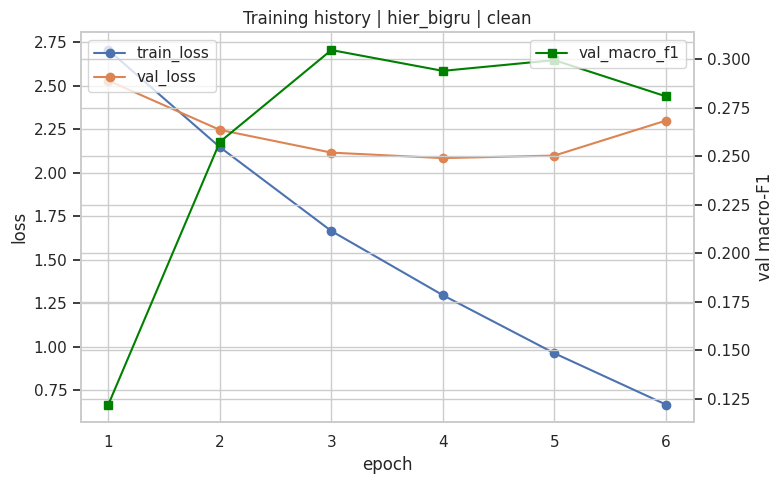

In [23]:
# cell 22: save training history (csv + figure)
history_df = pd.DataFrame(history_rows)
scenario_tag = HIER_SCENARIO
model_tag = "hier_bigru"

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

history_csv_path = f"{TABLES_DIR}/{model_tag}_{scenario_tag}_training_history.csv"
try:
    history_df.to_csv(history_csv_path, index=False, encoding="utf-8")
    print(f"Saved training history -> {history_csv_path}")
except Exception as exc:
    print(f"Не удалось сохранить {history_csv_path}: {exc}")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_df["epoch"], history_df["train_loss"], label="train_loss", marker="o")
ax1.plot(history_df["epoch"], history_df["val_loss"], label="val_loss", marker="o")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["val_macro_f1"], color="green",
         label="val_macro_f1", marker="s")
ax2.set_ylabel("val macro-F1")
ax2.legend(loc="upper right")
plt.title(f"Training history | {model_tag} | {scenario_tag}")
plt.tight_layout()
history_png_path = f"{FIGURES_DIR}/{model_tag}_{scenario_tag}_training_history.png"
try:
    fig.savefig(history_png_path, dpi=120, bbox_inches="tight")
    print(f"Saved training history figure -> {history_png_path}")
except Exception as exc:
    print(f"Не удалось сохранить {history_png_path}: {exc}")
plt.show()

if SAVE_MODEL:
    models_dir = f"{BASE_DIR}/models"
    try:
        os.makedirs(models_dir, exist_ok=True)
        state_path = f"{models_dir}/{model_tag}_{scenario_tag}_best.pt"
        torch.save(best_state, state_path)
        print(f"Saved best model -> {state_path}")
    except Exception as exc:
        print(f"Не удалось сохранить модель: {exc}")


## 13. Оценка на val и test и сохранение артефактов

FINAL VAL  loss=2.1161  macro_f1=0.3047
=== hier_bigru | clean | val ===
accuracy:    0.3286
macro-F1:    0.3047
weighted-F1: 0.3266
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.18      0.25      0.21         8
договоренность_или_планирование       0.00      0.00      0.00         3
            жалоба_или_проблема       0.36      0.89      0.52         9
              запрос_информации       0.25      0.17      0.20         6
     интервью_или_собеседование       0.22      0.25      0.24         8
                 личное_общение       0.50      0.33      0.40        15
              обсуждение_досуга       0.71      0.42      0.53        12
            обсуждение_здоровья       0.20      0.20      0.20         5
         обсуждение_путешествия       0.75      0.20      0.32        15
    обсуждение_работы_или_учебы       0.28      0.29      0.29        17
              покупка_или_заказ       0.75      0.50      0.60 

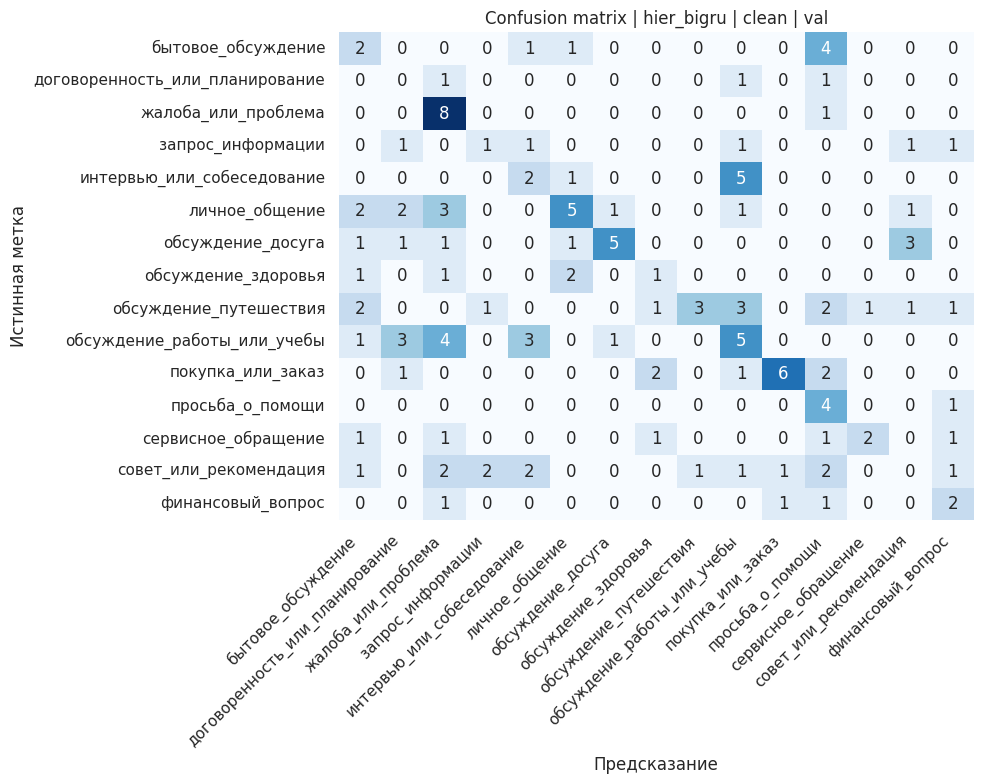

In [24]:
# cell 23: validation evaluation
val_loss, val_macro_f1, y_val_true, y_val_pred = evaluate_loader(model, val_loader, criterion)
print(f"FINAL VAL  loss={val_loss:.4f}  macro_f1={val_macro_f1:.4f}")
labels_for_report = list(range(NUM_CLASSES))
label_names = [id2label[i] for i in labels_for_report]
val_metrics = evaluate_predictions(
    y_val_true, y_val_pred,
    labels=labels_for_report,
    target_names=label_names,
    title=f"{model_tag} | {scenario_tag} | val",
)
# Confusion matrix с именами интентов на осях.
plot_confusion_matrix(
    val_metrics["confusion_matrix"], label_names,
    title=f"Confusion matrix | {model_tag} | {scenario_tag} | val",
)
record_result(model_tag, scenario_tag, "val", val_metrics)


FINAL TEST  loss=2.1296  macro_f1=0.3111
=== hier_bigru | clean | test ===
accuracy:    0.3500
macro-F1:    0.3111
weighted-F1: 0.3441
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.44      0.50      0.47         8
договоренность_или_планирование       0.00      0.00      0.00         3
            жалоба_или_проблема       0.22      0.67      0.33         9
              запрос_информации       0.50      0.33      0.40         6
     интервью_или_собеседование       0.00      0.00      0.00         7
                 личное_общение       1.00      0.20      0.33        15
              обсуждение_досуга       0.67      0.33      0.44        12
            обсуждение_здоровья       0.29      0.40      0.33         5
         обсуждение_путешествия       0.45      0.33      0.38        15
    обсуждение_работы_или_учебы       0.53      0.53      0.53        17
              покупка_или_заказ       0.41      0.58      0.4

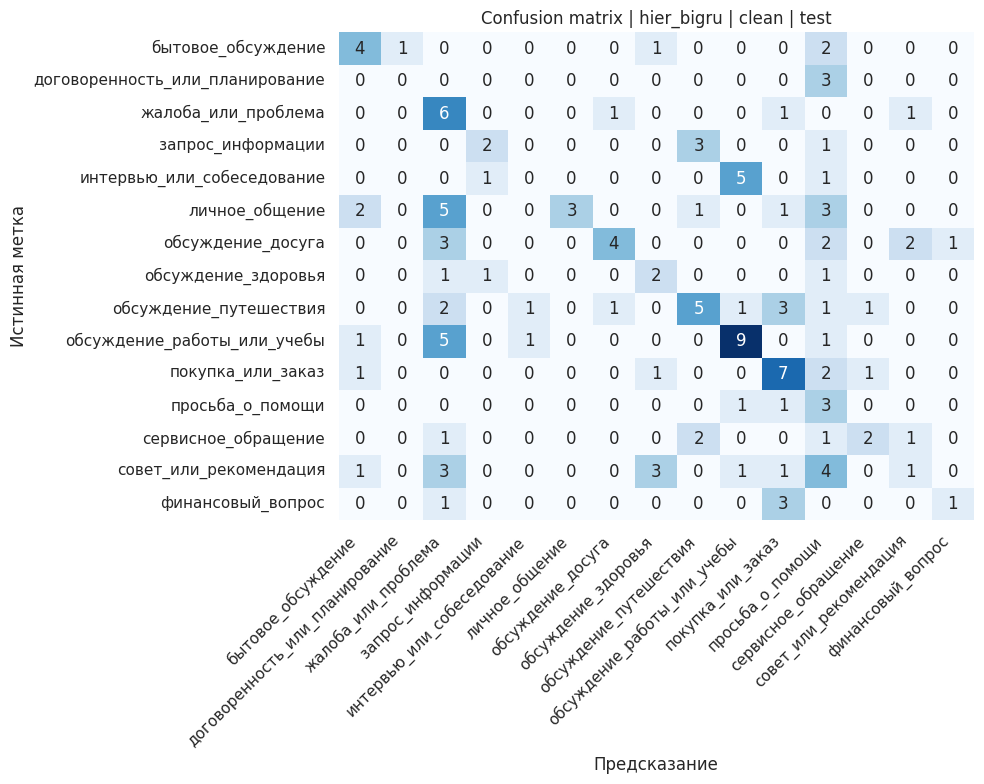

In [25]:
# cell 24: test evaluation
test_loss, test_macro_f1, y_test_true, y_test_pred = evaluate_loader(model, test_loader, criterion)
print(f"FINAL TEST  loss={test_loss:.4f}  macro_f1={test_macro_f1:.4f}")
test_metrics = evaluate_predictions(
    y_test_true, y_test_pred,
    labels=labels_for_report,
    target_names=label_names,
    title=f"{model_tag} | {scenario_tag} | test",
)
plot_confusion_matrix(
    test_metrics["confusion_matrix"], label_names,
    title=f"Confusion matrix | {model_tag} | {scenario_tag} | test",
)
record_result(model_tag, scenario_tag, "test", test_metrics)


In [26]:
# cell 25: save artifacts under stable names
def save_hier_artifacts(model_tag, scenario, split, metrics, y_true, y_pred, label_names,
                         tables_dir=None, figures_dir=None):
    tables_dir = tables_dir or TABLES_DIR
    figures_dir = figures_dir or FIGURES_DIR
    os.makedirs(tables_dir, exist_ok=True)
    os.makedirs(figures_dir, exist_ok=True)

    report_dict = classification_report(
        y_true, y_pred, labels=list(range(len(label_names))),
        target_names=label_names, output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_path = f"{tables_dir}/{model_tag}_{scenario}_classification_report_{split}.csv"
    report_df.to_csv(report_path, index=True, encoding="utf-8")

    cm = metrics.get("confusion_matrix")
    if cm is None:
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax, cbar=False)
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истинная метка")
    ax.set_title(f"Confusion matrix | {model_tag} | {scenario} | {split}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    cm_path = f"{figures_dir}/{model_tag}_{scenario}_confusion_matrix_{split}.png"
    fig.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"[save_hier_artifacts] {split}: {report_path}, {cm_path}")
    return {"report": report_path, "confusion_matrix": cm_path}


save_hier_artifacts(model_tag, scenario_tag, "val", val_metrics, y_val_true, y_val_pred, label_names)
save_hier_artifacts(model_tag, scenario_tag, "test", test_metrics, y_test_true, y_test_pred, label_names)


[save_hier_artifacts] val: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hier_bigru_clean_classification_report_val.csv, /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/hier_bigru_clean_confusion_matrix_val.png
[save_hier_artifacts] test: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hier_bigru_clean_classification_report_test.csv, /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/hier_bigru_clean_confusion_matrix_test.png


{'report': '/content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hier_bigru_clean_classification_report_test.csv',
 'confusion_matrix': '/content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/hier_bigru_clean_confusion_matrix_test.png'}

In [27]:
# cell 26: per-scenario metrics csv and test predictions csv
metrics_rows = [r for r in results_rows if r["model"] == model_tag and r["scenario"] == scenario_tag]
metrics_df = pd.DataFrame(metrics_rows, columns=["model", "scenario", "split", "accuracy", "macro_f1", "weighted_f1"])
metrics_path = f"{TABLES_DIR}/{model_tag}_{scenario_tag}_metrics.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")
print(f"Saved metrics -> {metrics_path}")

test_dialogids = [ex["dialogid"] for ex in test_examples]
test_isambig = [ex["isambiguous"] for ex in test_examples]
pred_df = pd.DataFrame({
    "dialogid": test_dialogids,
    "true_label": [id2label[int(y)] for y in y_test_true],
    "pred_label": [id2label[int(y)] for y in y_test_pred],
    "isambiguous": test_isambig,
})
pred_path = f"{TABLES_DIR}/{model_tag}_{scenario_tag}_test_predictions.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8")
print(f"Saved test predictions -> {pred_path}")


Saved metrics -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hier_bigru_clean_metrics.csv
Saved test predictions -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hier_bigru_clean_test_predictions.csv


In [28]:
# cell 27: aggregate hierarchical_metrics.csv across runs
agg_path = f"{TABLES_DIR}/hierarchical_metrics.csv"
new_rows = pd.DataFrame(metrics_rows, columns=["model", "scenario", "split", "accuracy", "macro_f1", "weighted_f1"])
try:
    if os.path.exists(agg_path):
        prev = pd.read_csv(agg_path)
        merged = pd.concat([prev, new_rows], ignore_index=True)
        merged = merged.drop_duplicates(subset=["model", "scenario", "split"], keep="last")
    else:
        merged = new_rows
    merged = merged.sort_values(["model", "scenario", "split"]).reset_index(drop=True)
    merged.to_csv(agg_path, index=False, encoding="utf-8")
    print(f"Saved aggregated metrics -> {agg_path}")
    print(merged)
except Exception as exc:
    print(f"Не удалось обновить {agg_path}: {exc}")


Saved aggregated metrics -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/hierarchical_metrics.csv
        model scenario split  accuracy  macro_f1  weighted_f1
0  hier_bigru    clean  test  0.350000  0.311095     0.344105
1  hier_bigru    clean   val  0.328571  0.304729     0.326624


## 14. Выводы

## Выводы по иерархической модели

В данном эксперименте была реализована иерархическая модель классификации интента диалога. Диалог предварительно разбивался на отдельные реплики, каждая реплика кодировалась с помощью `cointegrated/rubert-tiny2`, после чего последовательность репликовых представлений агрегировалась bidirectional GRU и передавалась в классификационную голову на 15 классов `primary_intent`.

Эксперимент проводился на `clean`-поднаборе, то есть без диалогов с `is_ambiguous == 1`. В текущем запуске transformer encoder был заморожен (`FREEZE_TRANSFORMER = True`), поэтому обучались только BiGRU и классификационная голова. Такой режим можно рассматривать как безопасный MVP-вариант иерархической архитектуры.

На validation split модель достигла следующих результатов:

| Split | Accuracy | Macro-F1 | Weighted-F1 |
|---|---:|---:|---:|
| validation | 0.3286 | 0.3047 | 0.3266 |
| test | 0.3500 | 0.3111 | 0.3441 |

Лучшее значение validation `macro-F1` было достигнуто на 3-й эпохе:

```text
Best val macro-F1 = 0.3047
```

После этого наблюдались признаки переобучения: `train_loss` продолжал снижаться, однако `val_macro_f1` уже не улучшался. Это говорит о том, что верхняя часть модели, состоящая из BiGRU и классификатора, начинает подстраиваться под обучающую выборку, но не даёт дальнейшего прироста качества на validation.

По сравнению с предыдущими baseline-подходами иерархическая модель в текущей конфигурации показала более слабый результат:

| Модель | Scenario | Test Macro-F1 |
|---|---|---:|
| TF-IDF + Logistic Regression | clean | 0.3856 |
| Transformer baseline | clean | 0.4104 |
| Hierarchical BiGRU | clean | 0.3111 |

Таким образом, текущая MVP-версия иерархической модели не превзошла baseline-модели. Наиболее вероятная причина заключается в том, что transformer encoder был заморожен и не адаптировался под задачу классификации интентов. В результате модель использовала фиксированные представления реплик, а обучаемая часть была ограничена BiGRU и классификационной головой.

Анализ per-class метрик показывает, что модель лучше распознаёт некоторые более тематически выраженные классы, например `обсуждение_работы_или_учебы`, `покупка_или_заказ`, `бытовое_обсуждение` и `обсуждение_досуга`. При этом часть классов остаётся проблемной: `договоренность_или_планирование`, `интервью_или_собеседование`, `совет_или_рекомендация` и некоторые другие интенты имеют низкие значения F1-score или не распознаются моделью устойчиво.

В целом эксперимент показывает, что учёт структуры диалога через последовательность реплик сам по себе не гарантирует улучшения качества. Для дальнейшего развития иерархического подхода необходимо протестировать частичную разморозку последних слоёв transformer encoder, использовать разные learning rate для encoder и верхних слоёв модели, а также дополнительно проанализировать ошибки на редких и семантически близких классах.

На текущем этапе основной рабочий результат для сравнения моделей целесообразно фиксировать по transformer baseline на `clean`-поднаборе, тогда как иерархическую модель рассматривать как дополнительный исследовательский эксперимент.